In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import skfuzzy as fuzz
from skfuzzy import control as ctrl

In [7]:
# ==== Opsional: Data Cleaning ====
data = pd.read_csv("dataset_pintu_otomatis_final.csv")

# Hapus baris kosong kalau ada
data = data.dropna()

# Pastikan tipe datanya numerik
data['jarak_cm'] = pd.to_numeric(data['jarak_cm'], errors='coerce')
data['kecepatan_ms'] = pd.to_numeric(data['kecepatan_ms'], errors='coerce')

# Simpan ulang versi bersih (opsional)
data.to_csv("dataset_pintu_otomatis_cleaned.csv", index=False)

print("Dataset cleaned and saved as dataset_pintu_otomatis_cleaned.csv")


Dataset cleaned and saved as dataset_pintu_otomatis_cleaned.csv


In [9]:
jarak = ctrl.Antecedent(np.arange(0, 201, 1), 'jarak')
kecepatan = ctrl.Antecedent(np.arange(0, 3.1, 0.1), 'kecepatan')
pintu = ctrl.Consequent(np.arange(0, 101, 1), 'pintu')

In [41]:
# Jarak (cm)
jarak['dekat'] = fuzz.trapmf(jarak.universe, [0, 0, 30, 70])
jarak['sedang'] = fuzz.trapmf(jarak.universe, [50, 80, 120, 160])
jarak['jauh'] = fuzz.trapmf(jarak.universe, [140, 180, 200, 200])

# Kecepatan (m/s)
kecepatan['lambat'] = fuzz.trapmf(kecepatan.universe, [0, 0, 0.4, 1.0])
kecepatan['sedang'] = fuzz.trapmf(kecepatan.universe, [0.8, 1.2, 1.8, 2.4])
kecepatan['cepat'] = fuzz.trapmf(kecepatan.universe, [2.0, 2.5, 3.0, 3.0])

# Bukaan pintu (%)
pintu['sedikit'] = fuzz.trimf(pintu.universe, [0, 0, 40])
pintu['normal'] = fuzz.trimf(pintu.universe, [30, 50, 70])
pintu['lebar'] = fuzz.trimf(pintu.universe, [60, 100, 100])

In [43]:
rule1 = ctrl.Rule(jarak['dekat'] & kecepatan['cepat'], pintu['lebar'])
rule2 = ctrl.Rule(jarak['dekat'] & kecepatan['lambat'], pintu['normal'])
rule3 = ctrl.Rule(jarak['sedang'] & kecepatan['cepat'], pintu['normal'])
rule4 = ctrl.Rule(jarak['sedang'] & kecepatan['lambat'], pintu['sedikit'])
rule5 = ctrl.Rule(jarak['jauh'] & kecepatan['lambat'], pintu['sedikit'])
rule6 = ctrl.Rule(jarak['jauh'] & kecepatan['cepat'], pintu['normal'])
rule7 = ctrl.Rule(jarak['sedang'] & kecepatan['sedang'], pintu['normal'])
rule8 = ctrl.Rule(jarak['dekat'] & kecepatan['sedang'], pintu['normal'])
rule9 = ctrl.Rule(jarak['jauh'] & kecepatan['sedang'], pintu['sedikit'])

In [49]:
pintu_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9])

In [99]:
hasil = []

for i, row in data.iterrows():
    pintu_sim.input['jarak'] = row['jarak_cm']
    pintu_sim.input['kecepatan'] = row['kecepatan_ms']
    pintu_sim.compute()
    hasil.append(pintu_sim.output['pintu'])

# Simpan hasil ke DataFrame dan ubah ke format persen tanpa desimal
data['bukaan_pintu'] = np.round(hasil).astype(int).astype(str) + '%'

# Ubah dulu kembali ke angka agar bisa dikategorikan
data['bukaan_pintu_num'] = data['bukaan_pintu'].str.replace('%', '').astype(float)

In [101]:
data['kategori_pintu'] = pd.cut(
    data['bukaan_pintu_num'],
    bins=[0, 40, 70, 100],
    labels=['Sedikit', 'Normal', 'Lebar']
)

In [115]:
# Hapus kolom 'bukaan_pintu_num' agar tidak tampil di hasil akhir
data = data.drop(columns=['bukaan_pintu_num'])

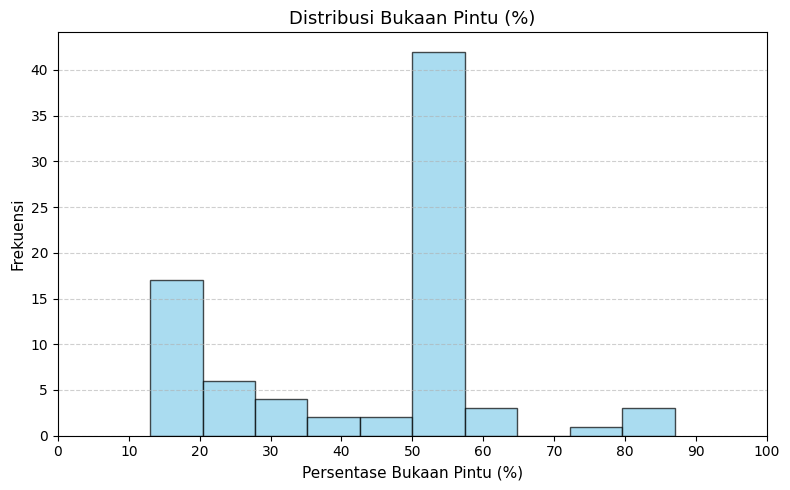

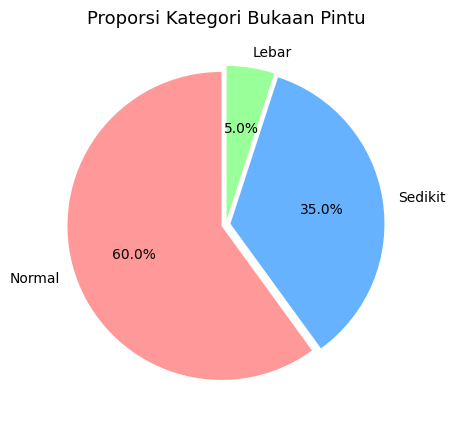

In [117]:
import matplotlib.pyplot as plt

# Pastikan nilai numerik tersedia (hapus tanda %)
data['bukaan_pintu_num'] = data['bukaan_pintu'].str.replace('%', '', regex=True).astype(float)

# === Histogram Distribusi Bukaan Pintu ===
plt.figure(figsize=(8,5))
plt.hist(data['bukaan_pintu_num'].round(1), bins=10, color='skyblue', edgecolor='black', alpha=0.7)
plt.title("Distribusi Bukaan Pintu (%)", fontsize=13)
plt.xlabel("Persentase Bukaan Pintu (%)", fontsize=11)
plt.ylabel("Frekuensi", fontsize=11)
plt.xticks(range(0, 101, 10))
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# === Pie Chart Kategori Bukaan Pintu ===
plt.figure(figsize=(5,5))
data['kategori_pintu'].value_counts().plot.pie(
    autopct='%1.1f%%',
    startangle=90,
    colors=['#FF9999', '#66B2FF', '#99FF99'],
    explode=(0.03, 0.03, 0.03)
)
plt.title("Proporsi Kategori Bukaan Pintu", fontsize=13)
plt.ylabel('')
plt.show()

In [135]:
data.to_csv('hasil_fuzzy_pintu.csv', index=False)

In [137]:
print(data.head())

   jarak  kecepatan persen_buka          kategori  bukaan_num
0    154       1.42         27%          Tertutup        27.0
1     91       3.00         50%  Setengah Terbuka        50.0
2     31       2.51         87%     Terbuka Penuh        87.0
3    181       2.11         27%          Tertutup        27.0
4     52       0.75         45%  Setengah Terbuka        45.0


In [133]:
data = data.rename(columns={
    "jarak_cm": "jarak",
    "kecepatan_ms": "kecepatan",
    "bukaan_pintu": "persen_buka",
    "kategori_pintu": "kategori",
    "bukaan_pintu_num": "bukaan_num"
})

data['kategori'] = data['kategori'].cat.rename_categories({
    "Sedikit": "Tertutup",
    "Normal": "Setengah Terbuka",
    "Lebar": "Terbuka Penuh"
})